<a href="https://colab.research.google.com/github/engmodu/AIFEL_quest_eng/blob/main/Computer_Vision/CV02/cv2_02_spaceCat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python pixellib

In [1]:
# cv2: OpenCV 라이브러리로, 실시간 컴퓨터 비전을 목적으로 한 프로그래밍 라이브러리
# numpy(NumPy): 행렬이나 대규모 다차원 배열을 쉽게 처리할 수 있도록 지원하는 라이브러리. 데이터 구조 외에도 수치 계산을 위해 효율적으로 구현된 기능을 제공
# torch: PyTorch. 딥러닝 및 텐서 연산을 위한 라이브러리. 인공지능 모델을 만들거나 불러와 추론하는 도구
# torchvision: 이미지 변환 및 전처리를 위한 torchvision의 transform 모듈
# deeplabv3_resnet101: 사전 학습된 DeepLabV3 모델. 이미지를 분류하도록 학습된 모델
# matplotlib: 파이썬 프로그래밍 언어 및 수학적 확장 NumPy 라이브러리를 활용한 플로팅 라이브러리로, 데이터 시각화 도구

import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

from google.colab import drive
drive.mount('/content/drive')



4.13.0
Mounted at /content/drive


원본 고양이 이미지 크기: (1024, 1536, 3)
배경(사막) 이미지 크기: (827, 620, 3)


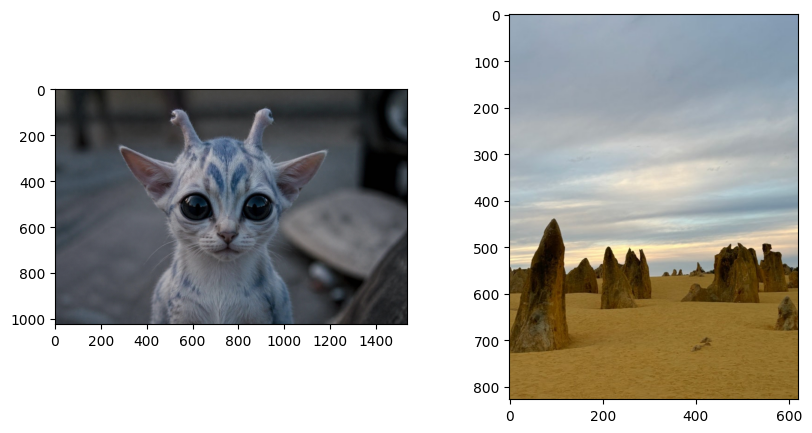

In [5]:
home_dir = os.path.join('/content/drive/MyDrive/data/')
cat_img_path = os.path.join(home_dir, 'human_segmentation/images/spaceCat.png') # 고양이
sand_img_path = os.path.join(home_dir, 'human_segmentation/images/sand.png') # 사막

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()


In [6]:
# DeepLabV3 + ResNet-101 기반의 사전학습된 세그멘테이션 모델 로드
# pretrained=True: COCO 등 데이터셋으로 학습된 가중치를 사용
# eval(): 추론 모드로 전환 (Dropout, BatchNorm 등 비활성화)
model = deeplabv3_resnet101(pretrained=True).eval()

# 입력 이미지 전처리 파이프라인 정의
transform = T.Compose([
    T.ToPILImage(),        # numpy 배열 또는 tensor 이미지를 PIL 이미지로 변환
                           # (torchvision transform은 PIL 기반이 많음)

    T.Resize((520, 520)), # 모델 입력 크기에 맞게 리사이즈
                           # DeepLabV3는 보통 520x520 입력을 기준으로 학습됨
                           # 비율 유지 없이 강제 리사이즈 → 객체 왜곡 가능성 있음

    T.ToTensor(),         # PIL 이미지를 torch.Tensor로 변환
                           # 값 범위를 [0, 255] → [0.0, 1.0]로 정규화
                           # shape: (H, W, C) → (C, H, W)
])

# 실제 이미지(cat_img)에 전처리 적용
# unsqueeze(0): 배치 차원 추가 → (C, H, W) → (1, C, H, W)
# 모델은 항상 배치 단위 입력을 요구하기 때문
input_tensor = transform(cat_img).unsqueeze(0)

# 추론 시 gradient 계산 비활성화 (메모리 절약 + 속도 향상)
with torch.no_grad():
    # 모델 forward pass
    # output은 dict 형태이며 "out" 키에 segmentation 결과가 담김
    # shape: (1, num_classes, H, W)
    output = model(input_tensor)["out"][0]

    # 각 픽셀마다 가장 높은 확률을 가진 클래스 선택
    # argmax(0): class 차원(num_classes) 기준으로 최대값 인덱스 선택
    # 결과 shape: (H, W)
    output_predictions = output.argmax(0).byte().cpu().numpy()

    # .byte(): uint8 타입으로 변환 (메모리 절약 및 이미지 처리 용이)
    # .cpu(): GPU → CPU로 이동
    # .numpy(): numpy 배열로 변환

# 결과 마스크 크기 출력
# 이 시점에서는 아직 원본 이미지 크기로 복원되지 않음 (520x520 유지)
print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:02<00:00, 100MB/s] 


추론 마스크 크기 (Before Resize): (520, 520)


In [7]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (1024, 1536)


In [8]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [0 8]


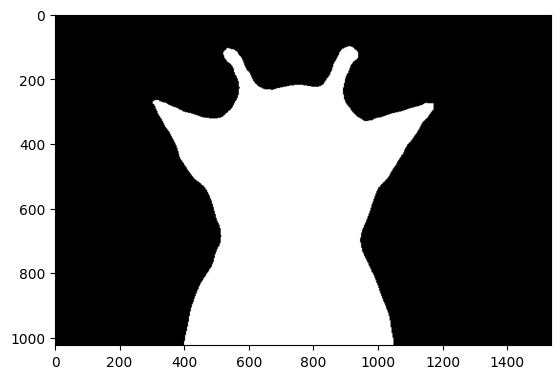

In [9]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

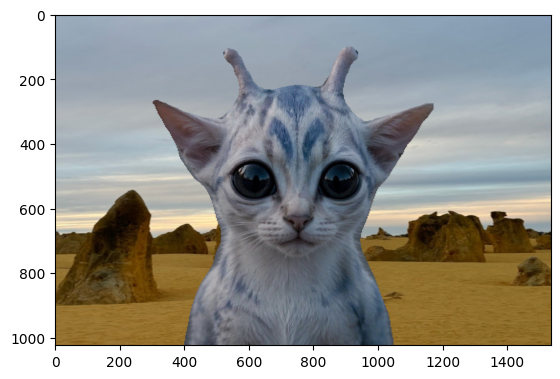

In [10]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()